<a href="https://colab.research.google.com/github/brishti-c/undergrad_ml_assignments/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is linear in its parameters (coefficients), meaning the outcome is a weighted sum of the features. The equation $y = \beta_0 + \beta_1x_1 + \beta_2x_2^2$ is linear because $\beta_1$ and $\beta_2$ are additive and not multiplied together.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

To interpret a dummy variable coefficient, you drop one category as a reference group. The intercept then represents the average outcome for that reference category. The coefficient for a dummy variable (e.g., Male) represents the average difference in the outcome between that category and the reference category (e.g., Female), assuming all else is equal.

3. Can linear regression be used for classification? Explain why, or why not.

No, linear regression should not be used for classification. It can produce predictions below 0 or above 1, which are invalid for probabilities. It is also highly sensitive to outliers, causing the regression line to shift and misclassify data points. Logistic regression is the appropriate tool for binary outcomes.

4. What are signs that your linear model is over-fitting?

The primary sign of overfitting is a large gap between training and test performance, where the model scores high on training data but poorly on unseen data. Other signs include very large coefficient values, as the model contorts to fit noise, and the model capturing random fluctuations in the data rather than the true underlying trend.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity happens when two or more variables are so similar that they explain the same thing. The two-stage least squares idea helps us see this. In the first stage, you try to predict one variable using the others. If you can predict it almost perfectly, that variable is redundant. In the second stage, this causes the model's coefficients to bounce around and become unreliable.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable  𝑦  and your features/control/response/independent variables  𝑥  into your analysis?

You can model nonlinear relationships while still using linear regression by transforming the features. Common methods include adding polynomial terms (like $x^2$), creating interaction terms ($x_1 \times x_2$), or using splines to fit smooth, flexible curves. Because the model remains linear in its coefficients, these transformed features allow the line to bend.

7. What is the interpretation of the slope coefficient in a linear regression?
The slope coefficient represents the marginal effect of a predictor.

Specifically, a one-unit increase in the predictor is associated with a slope-unit change in the outcome variable, holding all other variables constant. It captures the isolated relationship between that single feature and the target.

8. Compare the train/test split and  𝑘 -fold cross validation.

Train/test split divides your data once into a training set and a test set. It's quick and easy, but your results can change a lot depending on how you split.  𝑘 -fold cross validation splits the data into  𝑘  groups and trains the model  𝑘  times, each time testing on a different group. It gives a more reliable score but takes longer to run.

9. How is the  𝑘  in  𝑘 -fold cross validation typically selected?

The value of  𝑘  is typically chosen to balance bias and variance while considering computation time.  𝑘=5  or  𝑘=10  are the standard choices in practice.  𝑘=10  is common because it offers low bias (since the model trains on 90% of the data) without being as computationally expensive or high-variance as using  𝑘=𝑛 .

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

! git clone https://github.com/brishti-c/scratchpad
%run ./scratchpad/get_data.py

fatal: destination path 'scratchpad' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.

The most expensive bourough on average is Manhattan.

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

Based on the results of the regression, the conditional group means and the estimated coeffiencients are related in that adding the mean price in the Bronx (which was used as the reference by the regression) to the estimated coefficients gives us values very close to the actual mean prices in the various neighborhoods.

3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.

The slope coeffiecient tells us the expected change in nightly price for a 1-point increase in review score.

4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?

When both Neighbourhood and Review Scores Rating are included in the regression, the slope coefficient on review scores increases slightly from 1.0208 to 1.0811. This means that after controlling for neighborhood differences, a one-point increase in review score is associated with an increase of about 1.08 dollars in nightly price on average. The neighborhood coefficients remain very similar to those from the previous model that only included neighborhood variables, indicating that neighborhood differences explain much more of the variation in price than review scores. Overall, including review scores slightly adjusts the estimated neighborhood price differences but does not substantially change them.

5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?

Allowing each neighborhood to have its own slope for Review Scores Rating shows that the relationship between ratings and price is mostly similar across neighborhoods. The interaction terms for Brooklyn, Manhattan, and Queens are small and statistically insignificant, suggesting that the effect of review scores on price is roughly the same in those boroughs. However, Staten Island shows a very different slope, indicating that review scores may affect prices differently there. Overall, the results suggest that the rating–price relationship is generally consistent across most neighborhoods, with the exception of Staten Island.

6. Use cross validation to evaluate the models from parts 4, 5, and 6.

                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750


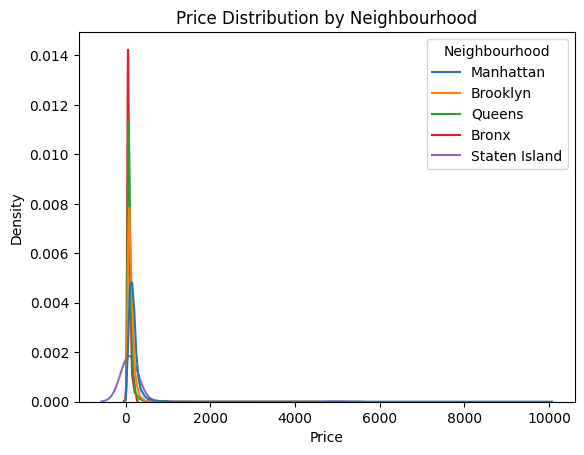

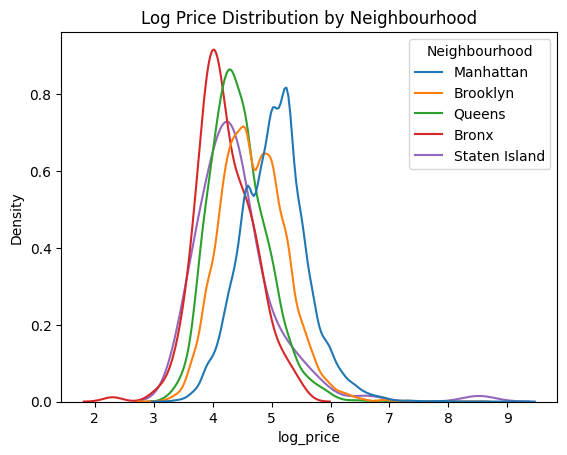

In [2]:
df = pd.read_csv('Q1_clean.csv', encoding='latin1')
df = df.rename(columns={'Neighbourhood ':'Neighbourhood'})

group_means = df.groupby('Neighbourhood')[['Price','Review Scores Rating']].mean()
print(group_means)

sns.kdeplot(data=df, x='Price', hue='Neighbourhood', common_norm=False)
plt.title("Price Distribution by Neighbourhood")
plt.show()

df['log_price'] = np.log(df['Price'])

sns.kdeplot(data=df, x='log_price', hue='Neighbourhood', common_norm=False)
plt.title("Log Price Distribution by Neighbourhood")
plt.show()

In [3]:
model1 = smf.ols("Price ~ C(Neighbourhood)", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        02:04:36   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [4]:
model2 = smf.ols("Price ~ Q('Review Scores Rating')", data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        02:04:36   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [5]:
model3 = smf.ols("Price ~ C(Neighbourhood) + Q('Review Scores Rating')", data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        02:04:36   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [6]:
model4 = smf.ols("Price ~ C(Neighbourhood) * Q('Review Scores Rating')", data=df).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:04:36   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

In [7]:
X = df[['Neighbourhood','Review Scores Rating']]
y = df['Price']

categorical = ['Neighbourhood']
numeric = ['Review Scores Rating']

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical),
        ("num", "passthrough", numeric)
    ]
)

pipelineA = Pipeline([
    ("prep", preprocess),
    ("model", LinearRegression())
])

df_inter = pd.get_dummies(df['Neighbourhood'], drop_first=True)

for col in df_inter.columns:
    df[col+"_rating"] = df_inter[col] * df['Review Scores Rating']

X2 = pd.concat([df_inter, df['Review Scores Rating'], df.filter(like="_rating")], axis=1)

kf = KFold(n_splits=5, shuffle=True, random_state=1)

scoresA = cross_val_score(pipelineA, X, y, cv=kf, scoring="neg_mean_squared_error")
print("Model A CV MSE:", -scoresA.mean())

modelB = LinearRegression()
scoresB = cross_val_score(modelB, X2, y, cv=kf, scoring="neg_mean_squared_error")
print("Model B CV MSE:", -scoresB.mean())

Model A CV MSE: 21068.500019790663
Model B CV MSE: 21293.768998593318


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?

  The distribution of car prices is right-skewed, with most vehicles priced in the lower to mid range and a smaller number of very expensive vehicles. When prices are grouped by Body_Type, larger vehicle types such as SUVs and MUVs tend to have the highest average prices, while hatchbacks generally have lower average prices. The grouped kernel density plot shows that SUVs and MUVs also exhibit a wider spread in prices, indicating greater variance. In contrast, hatchbacks and sedans tend to have more concentrated price distributions with less variation.

  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?

The regression of Price on Seating_Capacity produces a slope coefficient of approximately 59,270 rupees. This means that, on average, adding one additional seat is associated with an increase of about 59,000 rupees in the price of a vehicle. When seating capacity is treated as a categorical variable using one-hot encoding, the estimated price differences across seat counts are not perfectly proportional. Some seat categories have much larger or smaller price differences than others. This suggests that the relationship between seating capacity and price is not strictly linear, although there is still a general tendency for vehicles with more seats to be more expensive.

  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.

The model with degree 5 produced the lowest cross-validated mean squared error, indicating the best predictive performance.

  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?

The scatter plot of Price versus Age shows that vehicle prices generally decline as cars become older, although the relationship is not perfectly linear. Prices tend to drop more rapidly in the early years and then level off as vehicles age further. The polynomial regression model captures this curved pattern reasonably well, as the predicted line follows the overall downward trend in the data. While there is still substantial variability in prices for cars of the same age, the model provides a reasonable approximation of the main depreciation pattern over time.

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


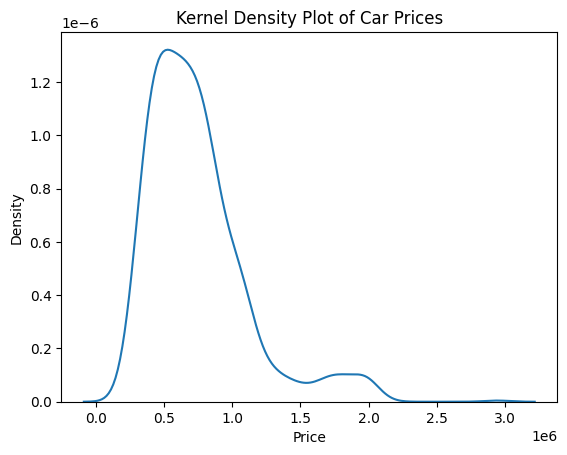

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


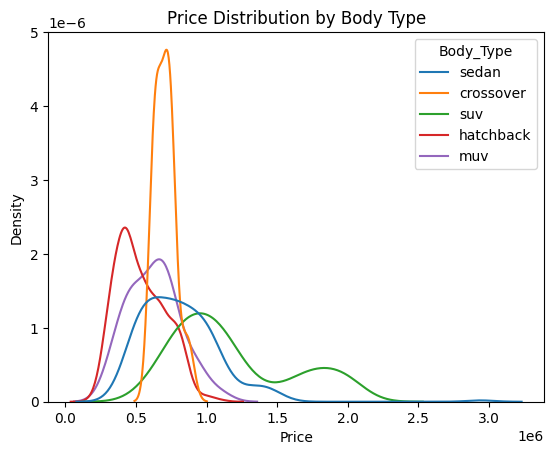

In [9]:
df = pd.read_csv('./data/cars_hw.csv', encoding='latin1')
print(df["Price"].describe())

sns.kdeplot(data=df, x="Price")
plt.title("Kernel Density Plot of Car Prices")
plt.show()

price_summary = df.groupby("Body_Type")["Price"].describe()
print(price_summary)

sns.kdeplot(data=df, x="Price", hue="Body_Type", common_norm=False)
plt.title("Price Distribution by Body Type")
plt.show()

In [11]:
model1 = smf.ols("Price ~ Seating_Capacity", data=df).fit()
print(model1.summary())

model2 = smf.ols("Price ~ C(Seating_Capacity)", data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Mon, 16 Mar 2026   Prob (F-statistic):             0.0245
Time:                        02:08:09   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

In [14]:
df["Age"] = 2024 - df["Make_Year"]

X = df[["Age"]]
y = df["Price"]

kf = KFold(n_splits=10, shuffle=True, random_state=1)

for d in range(1,6):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("linreg", LinearRegression())
    ])

    scores = cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error")

    print("Degree", d, "CV MSE:", -scores.mean())

Degree 1 CV MSE: 97745760011.44075
Degree 2 CV MSE: 97815319552.31636
Degree 3 CV MSE: 97304076284.3851
Degree 4 CV MSE: 96785385468.5632
Degree 5 CV MSE: 95816293470.54259


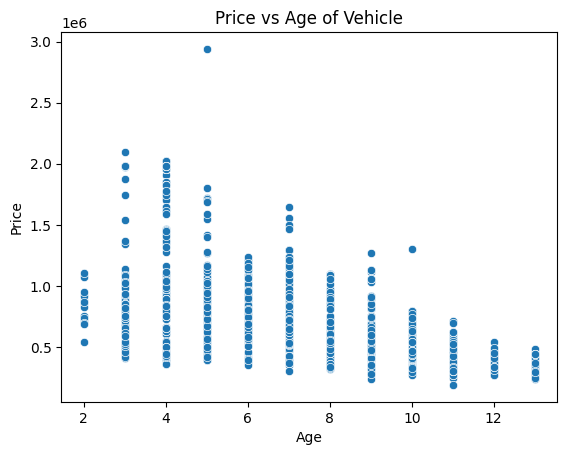

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


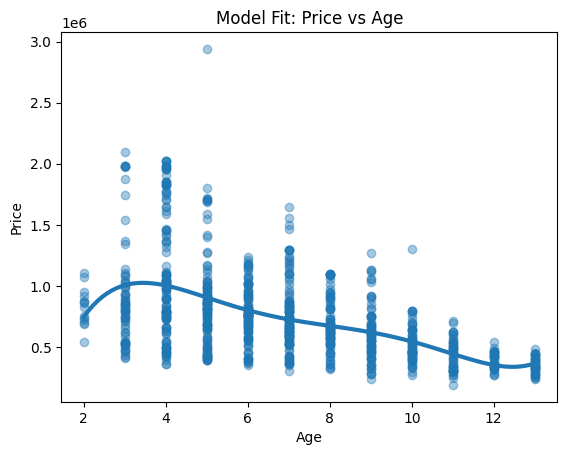

In [15]:
sns.scatterplot(data=df, x="Age", y="Price")
plt.title("Price vs Age of Vehicle")
plt.show()

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("linreg", LinearRegression())
])

poly_model.fit(X, y)

age_grid = np.linspace(df["Age"].min(), df["Age"].max(), 100).reshape(-1,1)
predicted_price = poly_model.predict(age_grid)

plt.scatter(df["Age"], df["Price"], alpha=0.4)
plt.plot(age_grid, predicted_price, linewidth=3)

plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Model Fit: Price vs Age")
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?

The proportion of patients who survived three years in the control group is 0.118, while the survival proportion in the treatment (transplant) group is 0.348. The average treatment effect (ATE) is calculated as the difference between these values: 0.348 − 0.118 = 0.230. This means that receiving a heart transplant is associated with about a 23 percentage point increase in the probability of surviving three years compared to not receiving a transplant.

2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.

The regression of survival on transplant status produces an intercept of 0.1176 and a transplant coefficient of 0.2302. The intercept represents the survival probability for the control group, which matches the control group mean from part 1. The transplant coefficient represents the difference in survival probability between the treatment and control groups, which matches the ATE computed earlier.

3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?

When age is included as a control variable, the transplant coefficient represents the effect of receiving a transplant while holding age constant. The intercept represents the predicted survival probability for a control patient when age equals zero, while the age coefficient shows how survival probability changes with age. The predicted survival plot shows that survival probabilities change with age, so the constant ATE line sometimes overestimates or underestimates the treatment effect depending on the age group.

4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?

Including an interaction between transplant and age allows the treatment effect to vary across ages. Instead of parallel prediction lines for treatment and control groups, the slopes can differ, meaning the benefit of a transplant changes as patients get older. This model captures patterns where transplants may be more beneficial for some age groups than others.

5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.

6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

If this model were used to prioritize transplant access, there could be several concerns. The model may suffer from selection bias because transplant recipients are not randomly assigned. It may also raise ethical concerns if certain groups are disadvantaged by the algorithm. Additionally, the model is predictive rather than causal, so relying on it alone could lead to incorrect conclusions about who would benefit most from a transplant.

In [17]:
df = pd.read_csv("heart_hw.csv", encoding="latin1")

survival_rates = df.groupby("transplant")["y"].mean()
print(survival_rates)
control_survival = survival_rates["control"]
treatment_survival = survival_rates["treatment"]

ATE = treatment_survival - control_survival

print("Control survival rate:", control_survival)
print("Treatment survival rate:", treatment_survival)
print("ATE:", ATE)

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE: 0.23017902813299232


In [20]:
model1 = smf.ols("y ~ C(transplant)", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Mon, 16 Mar 2026   Prob (F-statistic):             0.0133
Time:                        02:59:48   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           0.000357
Time:                        03:00:39   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

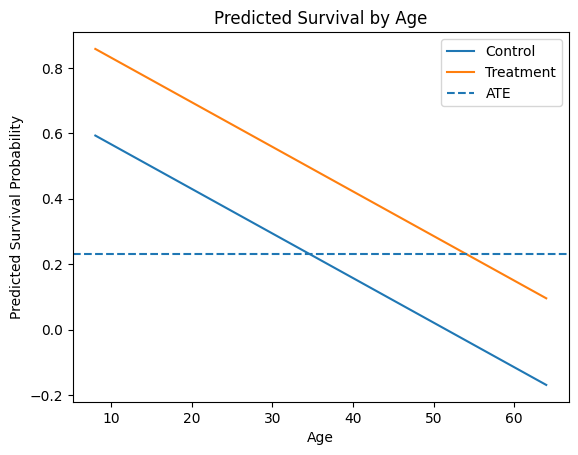

In [21]:
model2 = smf.ols("y ~ C(transplant) + age", data=df).fit()
print(model2.summary())

age_grid = np.linspace(df["age"].min(), df["age"].max(), 100)

control_pred = model2.predict(pd.DataFrame({
    "age": age_grid,
    "transplant": "control"
}))

treatment_pred = model2.predict(pd.DataFrame({
    "age": age_grid,
    "transplant": "treatment"
}))

plt.plot(age_grid, control_pred, label="Control")
plt.plot(age_grid, treatment_pred, label="Treatment")

plt.axhline(y=ATE, linestyle="dashed", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.title("Predicted Survival by Age")
plt.legend()
plt.show()

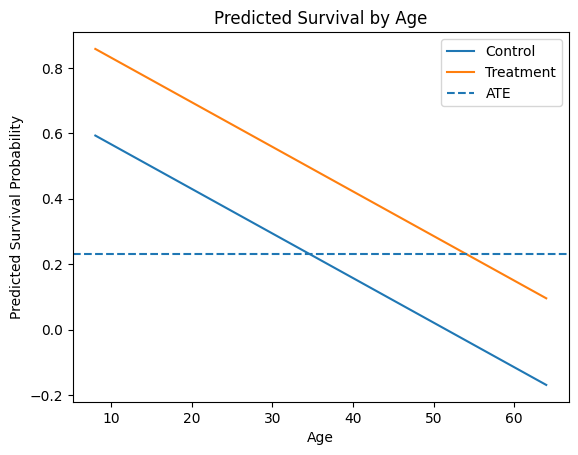

In [22]:
plt.plot(age_grid, control_pred, label="Control")
plt.plot(age_grid, treatment_pred, label="Treatment")

plt.axhline(y=ATE, linestyle="dashed", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.title("Predicted Survival by Age")
plt.legend()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           0.000310
Time:                        03:03:38   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

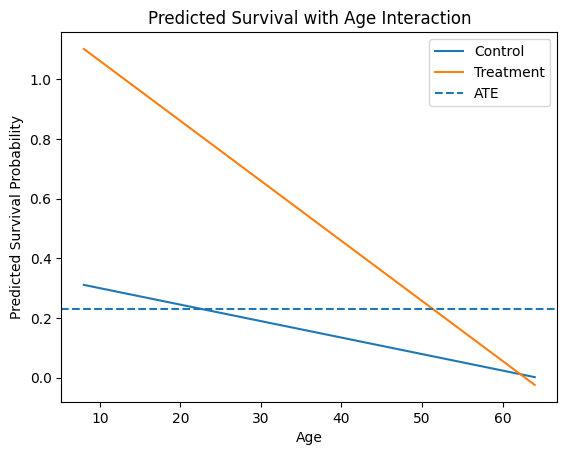

In [23]:
model3 = smf.ols("y ~ C(transplant) * age", data=df).fit()
print(model3.summary())

control_pred2 = model3.predict(pd.DataFrame({
    "age": age_grid,
    "transplant": "control"
}))

treatment_pred2 = model3.predict(pd.DataFrame({
    "age": age_grid,
    "transplant": "treatment"
}))

plt.plot(age_grid, control_pred2, label="Control")
plt.plot(age_grid, treatment_pred2, label="Treatment")

plt.axhline(y=ATE, linestyle="dashed", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.title("Predicted Survival with Age Interaction")
plt.legend()
plt.show()

In [24]:
X1 = pd.get_dummies(df["transplant"], drop_first=True)
y = df["y"]

kf = KFold(n_splits=10, shuffle=True, random_state=1)

scores1 = cross_val_score(LinearRegression(), X1, y,
                          cv=kf, scoring="neg_mean_squared_error")

print("Model 1 CV MSE:", -scores1.mean())

X2 = pd.concat([X1, df["age"]], axis=1)

scores2 = cross_val_score(LinearRegression(), X2, y,
                          cv=kf, scoring="neg_mean_squared_error")

print("Model 2 CV MSE:", -scores2.mean())

X3 = X2.copy()

X3["interaction"] = X1.iloc[:,0] * df["age"]

scores3 = cross_val_score(LinearRegression(), X3, y,
                          cv=kf, scoring="neg_mean_squared_error")

print("Model 3 CV MSE:", -scores3.mean())

Model 1 CV MSE: 0.19497249586192156
Model 2 CV MSE: 0.17926415954952163
Model 3 CV MSE: 0.17880206762517337
